# Results summary: BPTT vs PC vs RFLO, two-prior RSG (10-seed cluster sweep)

**Purpose:** hand-off summary for the team. This notebook only *reads* saved metrics
(`results/runs/*/seed_*/metrics.json`, via `scripts/summarize_runs.py`) and already-generated
figures (`scripts/plot_pc_activity.py`) — it does not retrain or recompute anything, per
`AGENTS.md` ("Plotting reads saved metrics ... never retrains").

**Four conditions**, all `reduced` regime (`dt=5`, `N=160`), `n_iter=3000`, real cluster runs
(jobs 317/327/347/349 + the RFLO sweep on `sld.umd.edu`):

| variant | rule | `pc_inference_steps` | seeds complete |
|---|---|---|---|
| `bptt` | BPTT | n/a | 10/10 |
| `pc_steps20` | PC | 20 (default) | 10/10 |
| `pc_steps100` | PC | 100 | 9/10 (seed 1 stopped at iter 2800/3000, wall-time limit — not resubmitted, excluded from behavior stats below) |
| `rflo` | RFLO | n/a | 10/10 |

**Known data gaps:**
- `pc_steps20`'s saved activation arrays (used for PCA/unit-activity/output-vs-target
  plots, *not* the metrics/behavior numbers) collided on the cluster with `pc_steps100`'s activation
  writes (both runs share the rule name `pc` and `pc_steps100` didn't have a separate `ACTIVATION_STORE`
  at submission time). 6 of 10 `pc_steps20` seeds lost their activations permanently; metrics/behavior are
  unaffected for all 10. See `has_activations` in the table below.
- RFLO was launched after that collision was fixed (`scripts/train.py`'s activation-store default is now
  derived from `--run-dir` itself), so its activations landed at `results/runs/activations/rflo/` on the
  cluster rather than the shared `results/activations/` root `bptt`/`pc` already use. Downloaded directly
  into `results/activations/rflo/` locally to match the existing convention — see
  `scripts/summarize_runs.py`'s `RUN_VARIANTS`, which also had a one-line bug (double-nested `rflo/rflo`
  lookup path) fixed alongside this.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display, Markdown

REPO_ROOT = Path.cwd().parent
df = pd.read_csv(REPO_ROOT / "results" / "runs_summary.csv")
df

,variant,rule,seed,complete,has_activations,best_loss,final_loss,n_iter_run,valid_tp_count,valid_tp_total,slope_short,slope_long
0,bptt,bptt,0,True,True,0.045501,0.129417,3000,0.0,20.0,NaN,NaN
1,bptt,bptt,1,True,True,0.043885,0.164219,3000,5.0,20.0,4.604794e-04,NaN
2,bptt,bptt,2,True,True,0.049972,0.300455,3000,0.0,20.0,NaN,NaN
3,bptt,bptt,3,True,True,0.015400,0.151933,3000,15.0,20.0,4.691929e-01,7.445434e-02
4,bptt,bptt,4,True,True,0.017672,0.025631,3000,20.0,20.0,-2.761231e-04,-4.482047e-05
5,bptt,bptt,5,True,True,0.003019,0.008125,3000,20.0,20.0,6.947057e-01,8.066678e-01
6,bptt,bptt,6,True,True,0.032699,0.175320,3000,10.0,20.0,1.835427e-02,1.066673e-03
7,bptt,bptt,7,True,True,0.028335,0.178592,3000,15.0,20.0,1.546309e-02,4.423301e-03
8,bptt,bptt,8,True,True,0.002373,0.005365,3000,20.0,20.0,7.882605e-01,7.635866e-01
9,bptt,bptt,9,True,True,0.039147,0.176443,3000,15.0,20.0,4.028055e-02,-3.771119e-03


## Per-variant summary (mean ± std over seeds)

Per `AGENTS.md` ("Seeds are the unit of evidence ... never report a single network per condition"),
always read this alongside the full per-seed table above, not instead of it.

In [2]:
complete = df[df["complete"]]
summary = complete.groupby("variant").agg(
    n_seeds=("seed", "count"),
    best_loss_mean=("best_loss", "mean"),
    best_loss_std=("best_loss", "std"),
    valid_tp_mean=("valid_tp_count", "mean"),
    valid_tp_std=("valid_tp_count", "std"),
    slope_short_mean=("slope_short", "mean"),
    slope_short_std=("slope_short", "std"),
    slope_long_mean=("slope_long", "mean"),
    slope_long_std=("slope_long", "std"),
).round(4)
summary

,n_seeds,best_loss_mean,best_loss_std,valid_tp_mean,valid_tp_std,slope_short_mean,slope_short_std,slope_long_mean,slope_long_std
variant,,,,,,,,,
bptt,10,0.0278,0.0174,12.0000,7.8881,0.2533,0.3408,0.2352,0.3769
pc_steps100,9,0.0076,0.0123,6.6667,8.2916,-0.2176,0.4746,0.0000,0.0000
pc_steps20,10,0.0287,0.0127,0.0000,0.0000,NaN,NaN,NaN,NaN
rflo,10,0.0343,0.0026,8.5000,6.2583,-0.0468,0.0962,0.0001,0.0053


## Key finding

- **BPTT** is genuinely seed-dependent: 2/10 seeds produce zero valid responses, 3/10 (seeds 3, 5, 8;
  also 6 is close) give clean positive slopes in the theoretically-expected Bayesian-bias range (long
  prior flatter than short), the rest partial. A real, honest spread — not a clean story.
- **PC at the default `pc_inference_steps=20`** collapses uniformly: **0/10 seeds** produce a single
  valid threshold crossing, despite loss converging in the same range as BPTT. The failure is the
  behavioral readout (flat, `ts`-independent output per prior×effector group), not a training failure.
- **PC at `pc_inference_steps=100`** breaks the uniform collapse — 4 of 9 seeds now show partial-to-full
  threshold crossings (seed 3, 4: 20/20; seed 0, 2: 5/20; seed 8: 10/20), and loss converges far lower
  (~1e-4 vs ~1e-2 for steps=20). **But the slopes are near-zero or negative**, not the positive
  Bayesian-bias slopes BPTT shows — i.e. steps=100 fixes threshold-crossing but not yet genuine
  interval-dependent, prior-modulated timing. Seed 2's slope (−1.07) is a clear outlier, worth a second
  look at that seed's raw output before treating it as representative.
- **RFLO** sits between BPTT and PC on threshold-crossing but not on the slope sign. All 10 seeds
  complete, `valid_tp_count` mean 8.5/20 (std 6.3, range 0–20) — a real per-seed spread like BPTT's,
  not PC-steps20's flat zero. `best_loss` (mean 0.034) is directly comparable to BPTT's (mean 0.028;
  both report the same `masked_mse`, unlike PC's `0.5×`-scaled loss) and lands in the same range.
  **But `slope_short` averages −0.047 (std 0.10)** — essentially flat-to-negative, not BPTT's positive
  mean (0.253). Only seeds 0 and 7 show small positive slopes (0.0023, 0.0029), orders of magnitude
  below BPTT's clean examples (0.69–0.79). `slope_long` is fittable for only 3/10 seeds at all (vs.
  BPTT's 6/10) and averages ~0 (0.0001, std 0.0053) — flatter than even RFLO's own short-prior slope.
  This is the specific signature `AGENTS.md` names as RFLO's expected weak point: its eligibility trace
  decays on a `tau=10ms` timescale, short against the 480–1200ms Ready→Set intervals this task requires
  crediting, so long-range temporal credit assignment should be where it struggles most — and the long
  prior (the longer, harder-to-credit intervals) is exactly where both the fit rate and the slope go
  flattest. Read as a graded result across the locality axis (BPTT nonlocal → RFLO local-and-online →
  PC's relaxation-based locality), not as "RFLO beats/loses to X," per `AGENTS.md`'s framing of the
  three-arm contrast.

Full technical trail (every hypothesis tested, exact numbers): `.suplex/docs/discrepancy_log.md`.
Narrative write-up: `docs/pc_threshold_finding.md`.

## Representative figures

Picked to illustrate the finding above, not as "the" result — the seed spread in the tables above is
the real evidence. Every seed's figures live under `results/figures/<variant>/seed_XXXX/`.

### BPTT seed 8 — clean Bayesian-bias example (best loss, slope_short=0.79, slope_long=0.76)

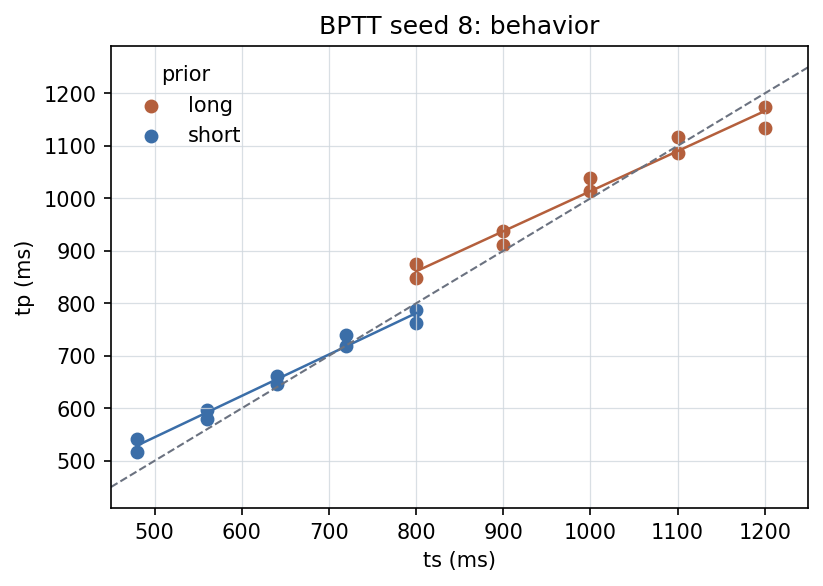

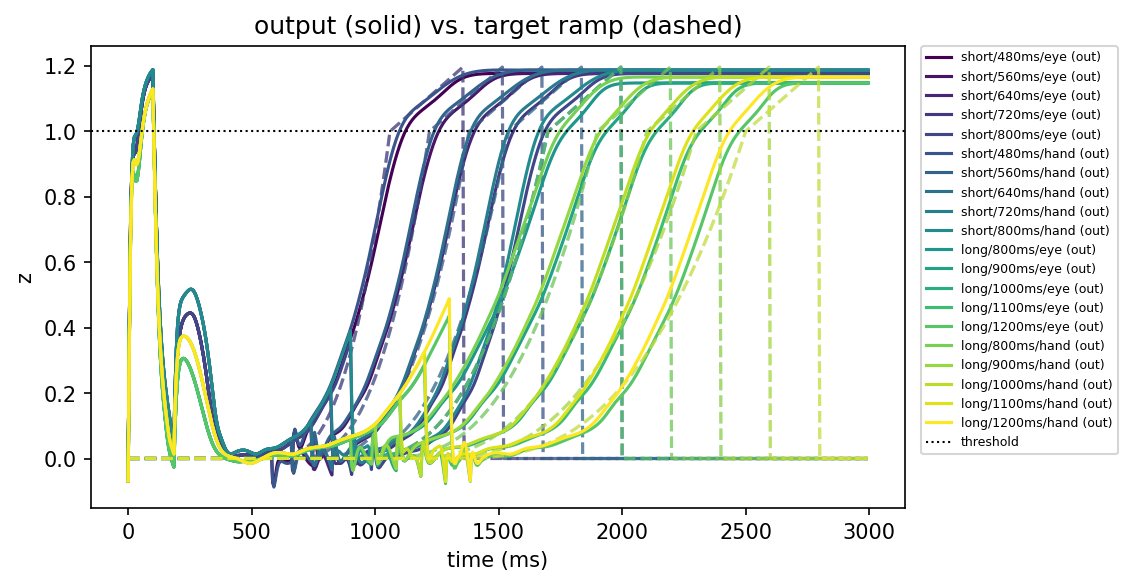

In [3]:
display(Image(filename=REPO_ROOT / "results/figures/bptt/seed_0008/bptt_seed0008_tp_vs_ts.png"))
display(Image(filename=REPO_ROOT / "results/figures/bptt/seed_0008/bptt_output_vs_target.png"))

### PC steps=20, seed 1 — flat collapse (0/20 valid, typical of all 10 seeds at this setting)

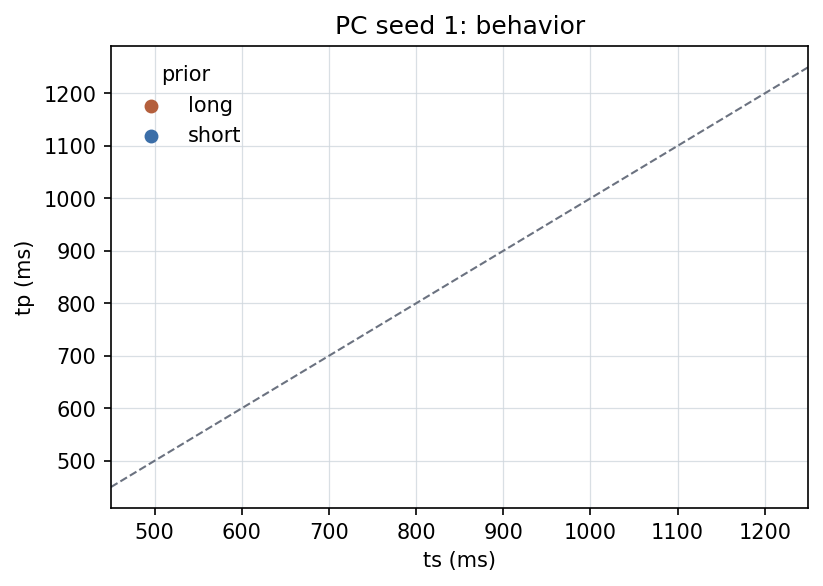

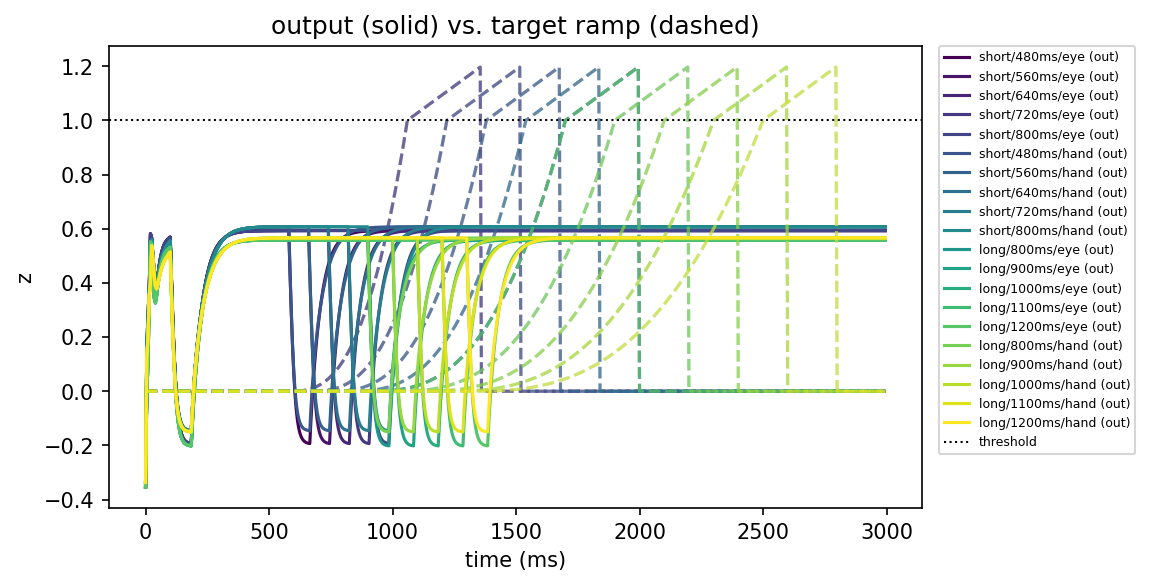

In [4]:
display(Image(filename=REPO_ROOT / "results/figures/pc_steps20/seed_0001/pc_seed0001_tp_vs_ts.png"))
display(Image(filename=REPO_ROOT / "results/figures/pc_steps20/seed_0001/pc_output_vs_target.png"))

### PC steps=100, seed 3 — 20/20 valid crossings, but non-Bayesian (near-zero/negative) slope

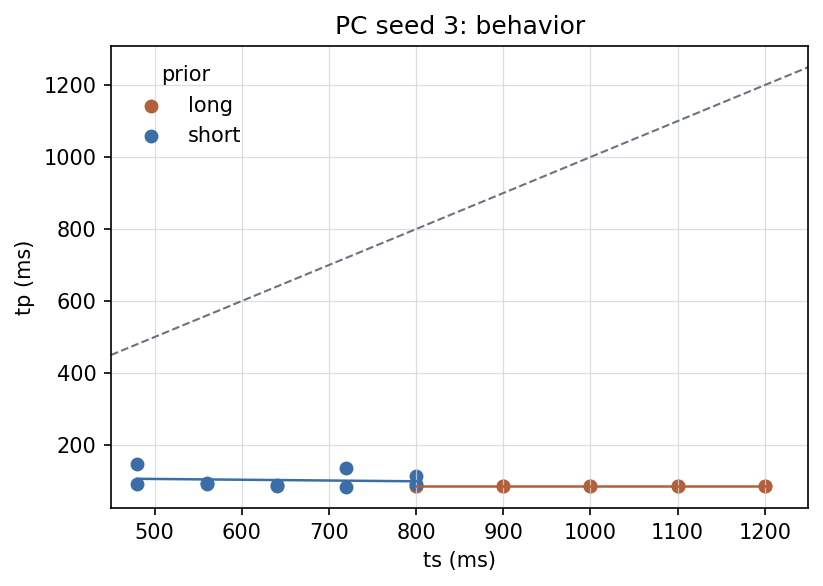

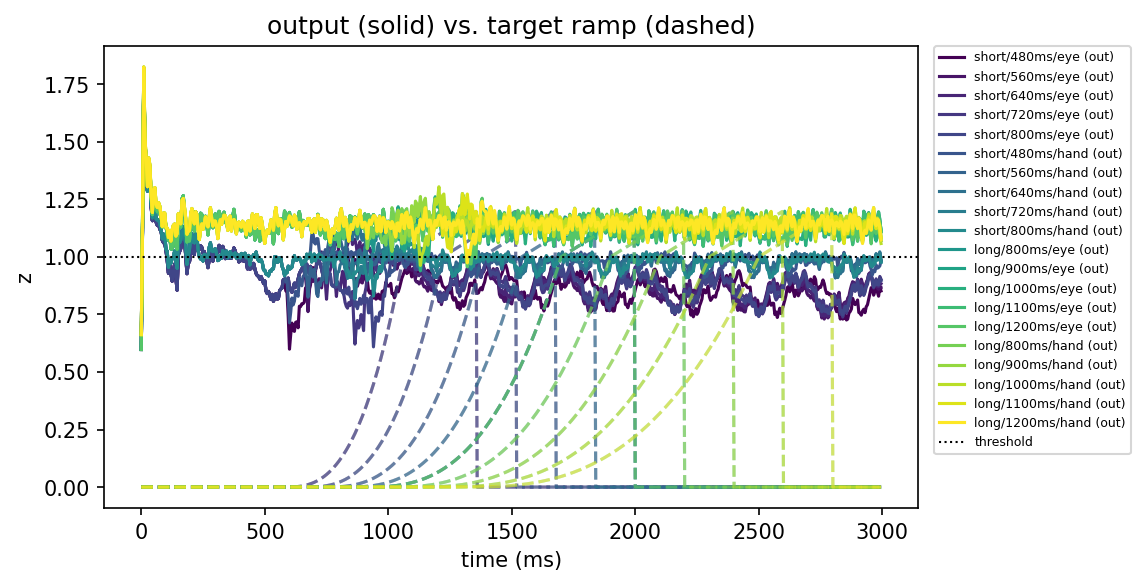

In [5]:
display(Image(filename=REPO_ROOT / "results/figures/pc_steps100/seed_0003/pc_seed0003_tp_vs_ts.png"))
display(Image(filename=REPO_ROOT / "results/figures/pc_steps100/seed_0003/pc_output_vs_target.png"))

### RFLO seed 7 — best case (20/20 valid, but tiny slope: slope_short=0.0029, slope_long=0.0002)

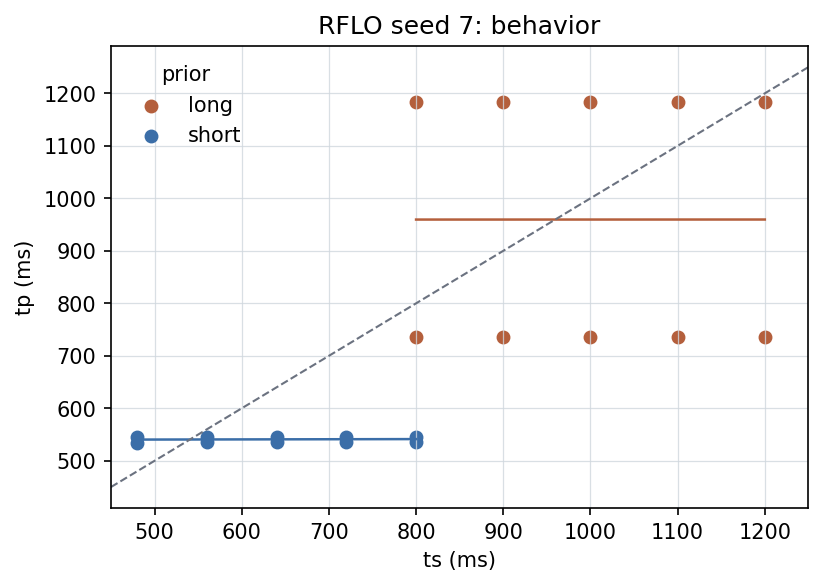

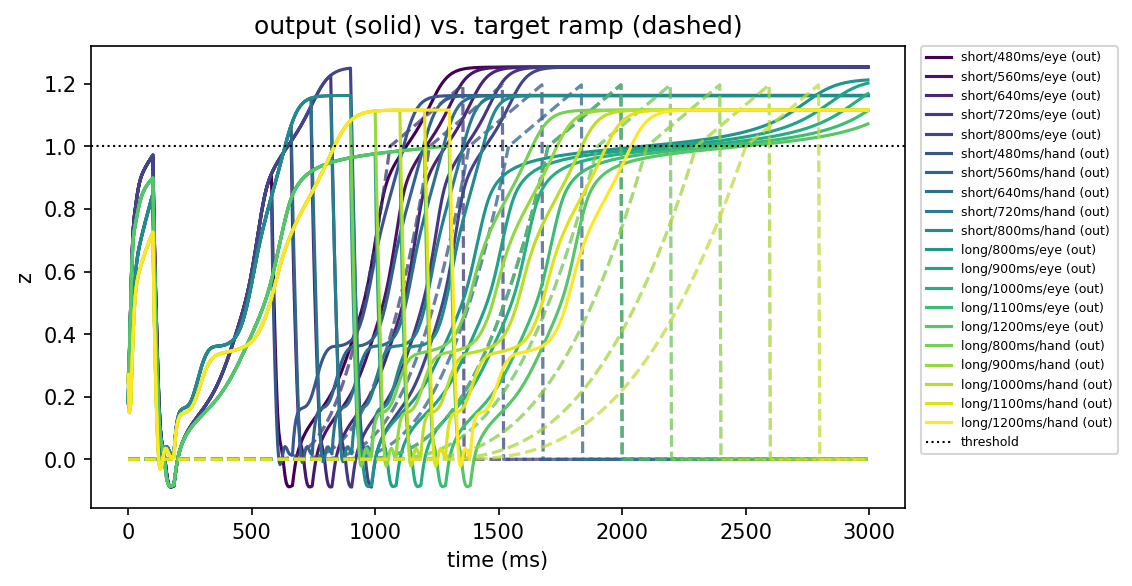

In [6]:
display(Image(filename=REPO_ROOT / "results/figures/rflo/seed_0007/rflo_seed0007_tp_vs_ts.png"))
display(Image(filename=REPO_ROOT / "results/figures/rflo/seed_0007/rflo_output_vs_target.png"))

### RFLO seed 6 — collapse case (0/20 valid, typical of the low end of RFLO's spread)

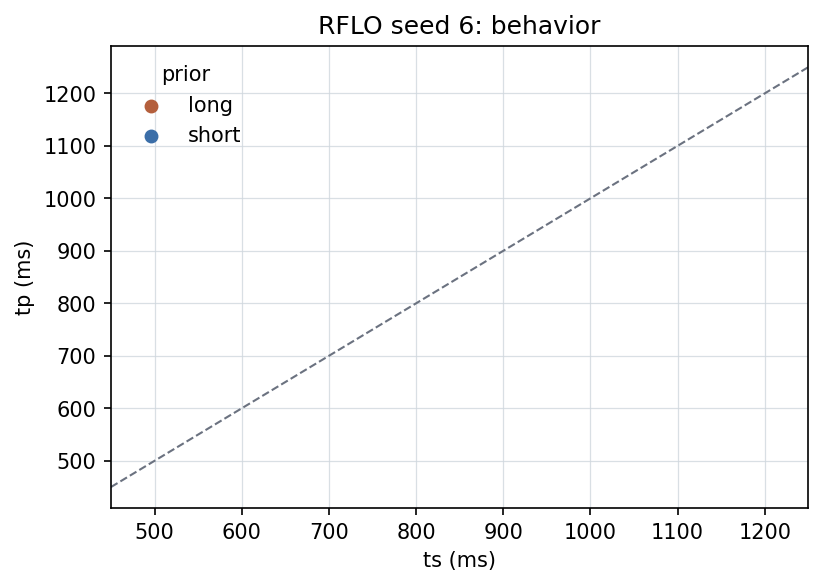

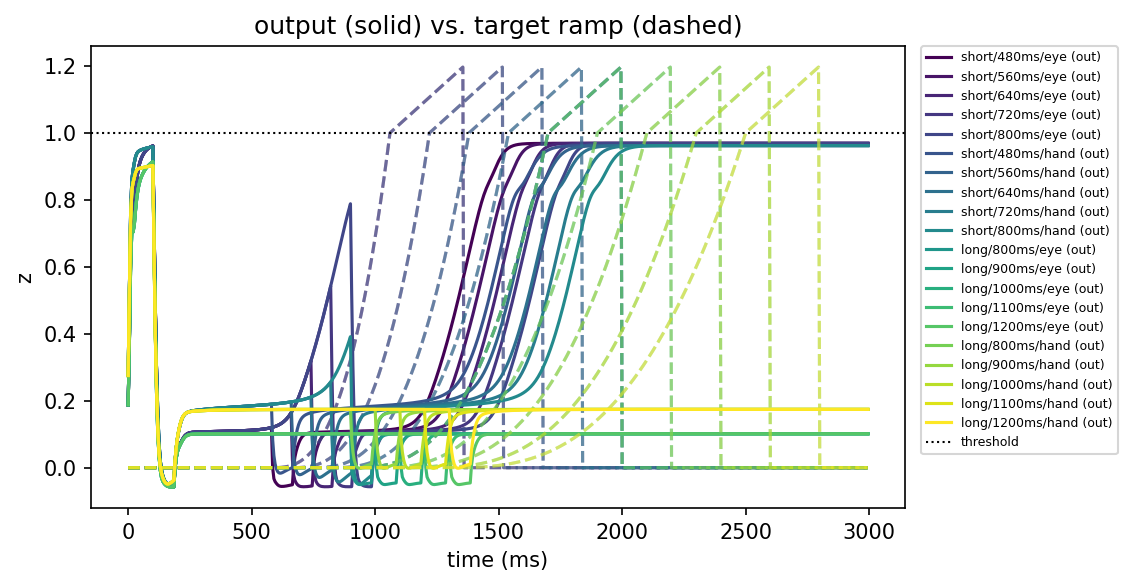

In [7]:
display(Image(filename=REPO_ROOT / "results/figures/rflo/seed_0006/rflo_seed0006_tp_vs_ts.png"))
display(Image(filename=REPO_ROOT / "results/figures/rflo/seed_0006/rflo_output_vs_target.png"))

## BPTT vs PC vs RFLO: RSA / iDSA (model-to-model, no DMFC)

Rule-vs-rule only — DMFC comparison is still blocked (no neural data ingested; see below). Seed
coverage is limited to seeds where *both* rules being compared have surviving activations: 4 shared
seeds for `pc_steps20` (1, 5, 7, 9 — the other 6 lost activations to the collision described above), 9
for `pc_steps100` (0, 2–9; seed 1 excluded, incomplete run), all 10 for `bptt` and `rflo`. Computed via
`scripts/run_rsa.py` / `scripts/run_idsa.py --backend builtin` (the `dsa-metric` package isn't installed
in this env, so iDSA falls back to the built-in numpy estimator — same math, no official-package
dependency).

`src.compare.rsa.rsa_distances_per_seed` and `scripts/run_idsa.py`'s rule-vs-rule path both already
generalize to every unordered pair of `--rules` passed (not just two), so no comparison code changed to
add RFLO here — three rules give `bptt_vs_pc`, `bptt_vs_rflo`, `pc_vs_rflo`. The only wrinkle: `pc`'s
activations live in their own store roots (`results/activations/pc_steps20`,
`results/activations/pc_steps100`) to keep the two PC hyperparameter variants from colliding, while
`bptt`/`rflo` share the flat `results/activations` root — so a `pc`-vs-`rflo` comparison needs RFLO's
records copied alongside `pc`'s in each of those two store roots first (done below the JSON loads, not
re-run each time this notebook executes).

RSA distance and iDSA distance are different metrics on different scales — don't compare their
absolute magnitudes to each other, only within each metric. Both are raw distances (no DMFC noise
ceiling to normalize against yet), so treat these as a first look at the seed spread, not calibrated
numbers.

In [8]:
import json

rsa_20 = json.loads((REPO_ROOT / "results/rsa/bptt_vs_pc_steps20/rsa_distances.json").read_text())
rsa_100 = json.loads((REPO_ROOT / "results/rsa/bptt_vs_pc_steps100/rsa_distances.json").read_text())
idsa_20 = json.loads((REPO_ROOT / "results/idsa/bptt_vs_pc_steps20/idsa_distances.json").read_text())
idsa_100 = json.loads((REPO_ROOT / "results/idsa/bptt_vs_pc_steps100/idsa_distances.json").read_text())

rsa_rows = []
for variant, seeds, payload in [("pc_steps20", [1, 5, 7, 9], rsa_20), ("pc_steps100", [0, 2, 3, 4, 5, 6, 7, 8, 9], rsa_100)]:
    for seed, dist in zip(seeds, payload["distances"]["RSA"]["bptt_vs_pc"]):
        rsa_rows.append({"variant": variant, "seed": seed, "rsa_distance": dist})
rsa_df = pd.DataFrame(rsa_rows)
display(Markdown("**RSA distance (BPTT vs PC), per seed**"))
display(rsa_df)
display(rsa_df.groupby("variant")["rsa_distance"].agg(["mean", "std"]).round(4))

**RSA distance (BPTT vs PC), per seed**

,variant,seed,rsa_distance
0,pc_steps20,1,0.684707
1,pc_steps20,5,0.625804
2,pc_steps20,7,0.630743
3,pc_steps20,9,0.513481
4,pc_steps100,0,0.689334
5,pc_steps100,2,0.712878
6,pc_steps100,3,0.386065
7,pc_steps100,4,0.193723
8,pc_steps100,5,0.776633
9,pc_steps100,6,0.233929


,mean,std
variant,,
pc_steps100,0.5736,0.2390
pc_steps20,0.6137,0.0719


In [9]:
rsa_bptt_rflo = json.loads((REPO_ROOT / "results/rsa/bptt_vs_rflo/rsa_distances.json").read_text())
rsa_pc20_rflo = json.loads((REPO_ROOT / "results/rsa/pc_steps20_vs_rflo/rsa_distances.json").read_text())
rsa_pc100_rflo = json.loads((REPO_ROOT / "results/rsa/pc_steps100_vs_rflo/rsa_distances.json").read_text())

rsa_rflo_rows = []
for pair_label, seeds, payload, key in [
    ("bptt_vs_rflo", [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], rsa_bptt_rflo, "bptt_vs_rflo"),
    ("pc_steps20_vs_rflo", [1, 5, 7, 9], rsa_pc20_rflo, "pc_vs_rflo"),
    ("pc_steps100_vs_rflo", [0, 2, 3, 4, 5, 6, 7, 8, 9], rsa_pc100_rflo, "pc_vs_rflo"),
]:
    for seed, dist in zip(seeds, payload["distances"]["RSA"][key]):
        rsa_rflo_rows.append({"pair": pair_label, "seed": seed, "rsa_distance": dist})
rsa_rflo_df = pd.DataFrame(rsa_rflo_rows)
display(Markdown("**RSA distance, RFLO vs BPTT / PC, per seed**"))
display(rsa_rflo_df)
display(rsa_rflo_df.groupby("pair")["rsa_distance"].agg(["mean", "std"]).round(4))

**RSA distance, RFLO vs BPTT / PC, per seed**

,pair,seed,rsa_distance
0,bptt_vs_rflo,0,0.245010
1,bptt_vs_rflo,1,0.218758
2,bptt_vs_rflo,2,0.434447
3,bptt_vs_rflo,3,0.293057
4,bptt_vs_rflo,4,0.408247
5,bptt_vs_rflo,5,0.391828
6,bptt_vs_rflo,6,0.271987
7,bptt_vs_rflo,7,0.144506
8,bptt_vs_rflo,8,0.231721
9,bptt_vs_rflo,9,0.568827


,mean,std
pair,,
bptt_vs_rflo,0.3208,0.1271
pc_steps100_vs_rflo,0.4959,0.1052
pc_steps20_vs_rflo,0.5468,0.0141


In [10]:
idsa_rows = []
for variant, payload in [("pc_steps20", idsa_20), ("pc_steps100", idsa_100)]:
    for seed_str, d in payload["per_seed"].items():
        idsa_rows.append({"variant": variant, "seed": int(seed_str), **d})
idsa_df = pd.DataFrame(idsa_rows)
display(Markdown("**iDSA distance (BPTT vs PC), per seed** (`distance` = combined; `state_distance` /"
                  " `input_distance` = its recurrent- vs input-structure components)"))
display(idsa_df)
display(idsa_df.groupby("variant")[["distance", "state_distance", "input_distance"]].agg(["mean", "std"]).round(2))

**iDSA distance (BPTT vs PC), per seed** (`distance` = combined; `state_distance` / `input_distance` = its recurrent- vs input-structure components)

,variant,seed,distance,input_distance,state_distance
0,pc_steps20,1,224.937179,27.277504,23.870849
1,pc_steps20,5,1769.567209,51.233346,88.813414
2,pc_steps20,7,3022.714093,26.309765,94.069034
3,pc_steps20,9,1465.091042,28.829779,48.819810
4,pc_steps100,0,710.834213,13.487125,16.342610
5,pc_steps100,2,435.601029,34.181569,19.028622
6,pc_steps100,3,151.711259,37.714216,5.279544
7,pc_steps100,4,5136.270070,31.380049,232.089672
8,pc_steps100,5,2574.944590,51.149095,58.713508
9,pc_steps100,6,724.285365,59.306430,145.864498


distance          state_distance        input_distance       
                mean      std           mean    std           mean    std
variant                                                                  
pc_steps100  2075.63  2148.50          92.40  82.59          35.25  13.44
pc_steps20   1620.58  1148.94          63.89  33.47          33.41  11.93

In [11]:
# Schema note: these three files were generated by the current scripts/run_idsa.py, which
# nests results under "per_seed_by_pair" (one key per unordered rule pair) so a third rule
# doesn't get silently dropped. The older bptt_vs_pc_steps20/100 files loaded above predate
# that generalization and use a flat "per_seed" key instead -- real drift between two saved
# JSON schemas on disk, not a bug in either read below; flagging rather than silently
# regenerating the older files, since that's a separate call (re-running iDSA for bptt-vs-pc
# isn't part of this pass).
idsa_bptt_rflo = json.loads((REPO_ROOT / "results/idsa/bptt_vs_rflo/idsa_distances.json").read_text())
idsa_pc20_rflo = json.loads((REPO_ROOT / "results/idsa/pc_steps20_vs_rflo/idsa_distances.json").read_text())
idsa_pc100_rflo = json.loads((REPO_ROOT / "results/idsa/pc_steps100_vs_rflo/idsa_distances.json").read_text())

idsa_rflo_rows = []
for pair_label, payload, key in [
    ("bptt_vs_rflo", idsa_bptt_rflo, "bptt_vs_rflo"),
    ("pc_steps20_vs_rflo", idsa_pc20_rflo, "pc_vs_rflo"),
    ("pc_steps100_vs_rflo", idsa_pc100_rflo, "pc_vs_rflo"),
]:
    for seed_str, d in payload["per_seed_by_pair"][key].items():
        idsa_rflo_rows.append({"pair": pair_label, "seed": int(seed_str), **d})
idsa_rflo_df = pd.DataFrame(idsa_rflo_rows)
display(Markdown("**iDSA distance, RFLO vs BPTT / PC, per seed** (`distance` = combined; "
                  "`state_distance` / `input_distance` = its recurrent- vs input-structure components)"))
display(idsa_rflo_df)
display(idsa_rflo_df.groupby("pair")[["distance", "state_distance", "input_distance"]].agg(["mean", "std"]).round(2))

**iDSA distance, RFLO vs BPTT / PC, per seed** (`distance` = combined; `state_distance` / `input_distance` = its recurrent- vs input-structure components)

,pair,seed,distance,input_distance,state_distance
0,bptt_vs_rflo,0,601.837598,36.072748,14.195513
1,bptt_vs_rflo,1,656.471807,31.237708,4.415498
2,bptt_vs_rflo,2,113.346266,17.739076,4.898450
3,bptt_vs_rflo,3,866.012337,20.560885,10.104082
4,bptt_vs_rflo,4,931.053446,20.193966,25.948220
5,bptt_vs_rflo,5,2372.784841,41.751535,28.356056
6,bptt_vs_rflo,6,334.269956,48.411882,10.043019
7,bptt_vs_rflo,7,650.103629,31.094460,12.449074
8,bptt_vs_rflo,8,986.320957,38.495823,10.455369
9,bptt_vs_rflo,9,1409.079317,14.676810,10.486728


distance          state_distance        input_distance  \
                        mean      std           mean    std           mean   
pair                                                                         
bptt_vs_rflo          892.13   631.29          13.14   7.99          30.02   
pc_steps100_vs_rflo  2205.97  1913.14          87.81  80.07          32.54   
pc_steps20_vs_rflo   1858.64   922.45          57.77  28.29          36.06   

                            
                       std  
pair                        
bptt_vs_rflo         11.35  
pc_steps100_vs_rflo  14.83  
pc_steps20_vs_rflo   13.04

**bptt_vs_rflo**

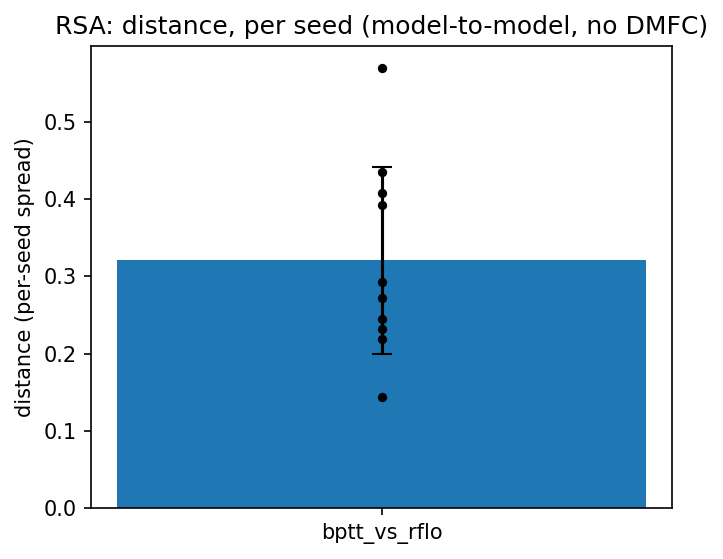

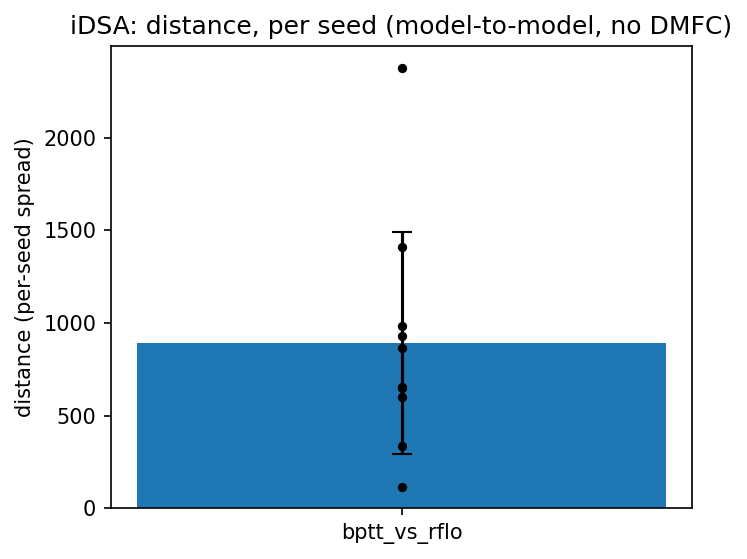

**pc_steps20_vs_rflo**

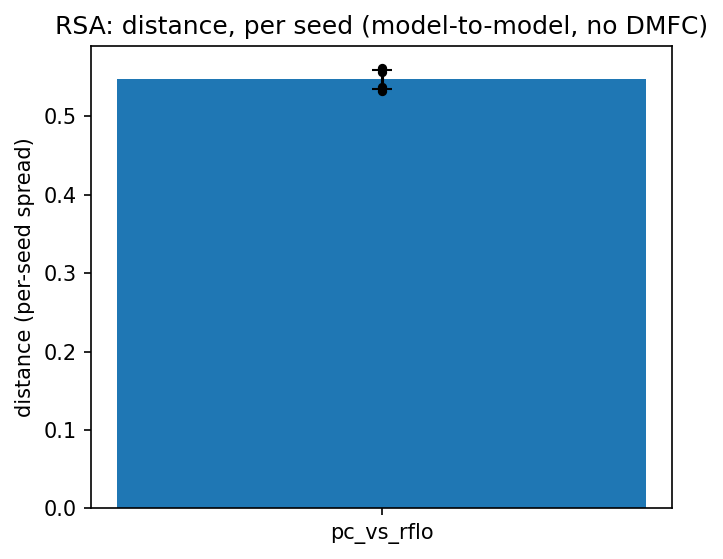

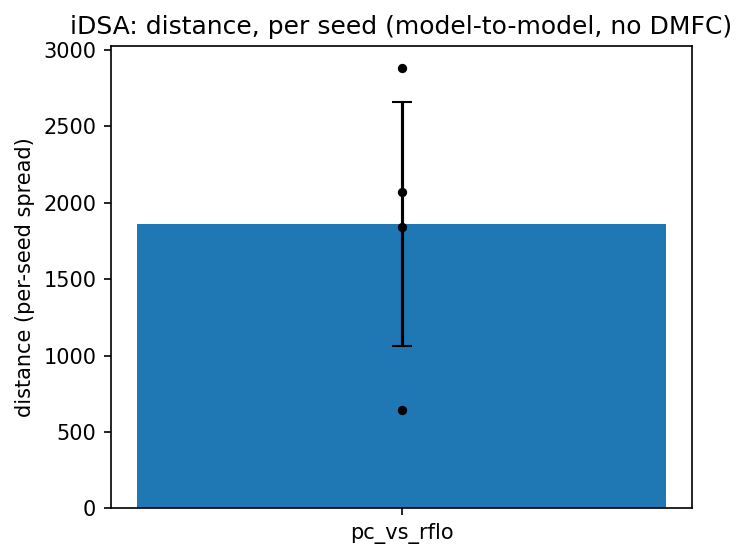

**pc_steps100_vs_rflo**

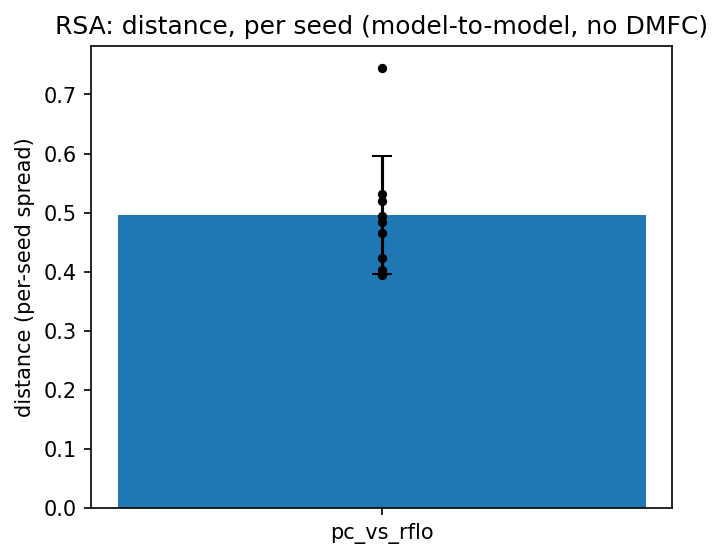

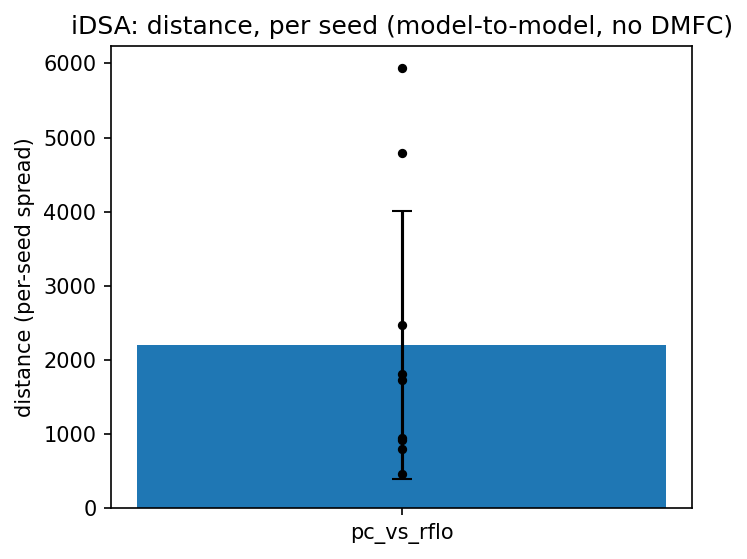

In [12]:
for pair in ["bptt_vs_rflo", "pc_steps20_vs_rflo", "pc_steps100_vs_rflo"]:
    display(Markdown(f"**{pair}**"))
    display(Image(filename=REPO_ROOT / f"results/rsa/{pair}/figures/summary_distance_model_to_model.png"))
    display(Image(filename=REPO_ROOT / f"results/idsa/{pair}/figures/summary_distance_model_to_model.png"))

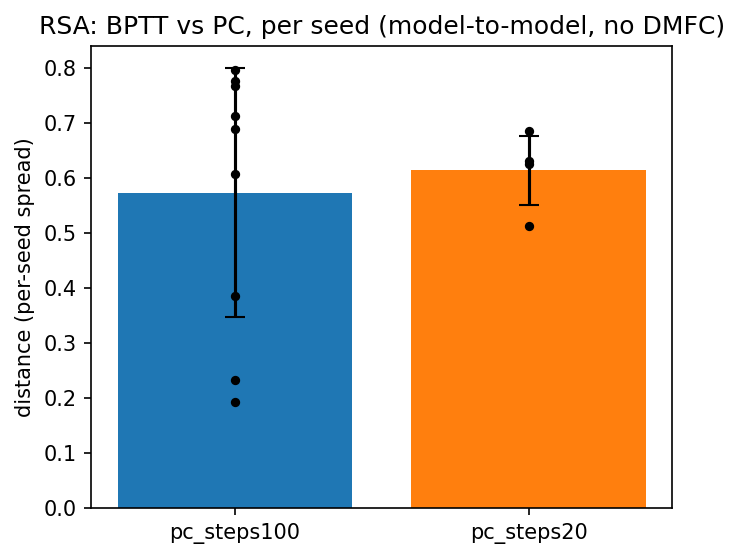

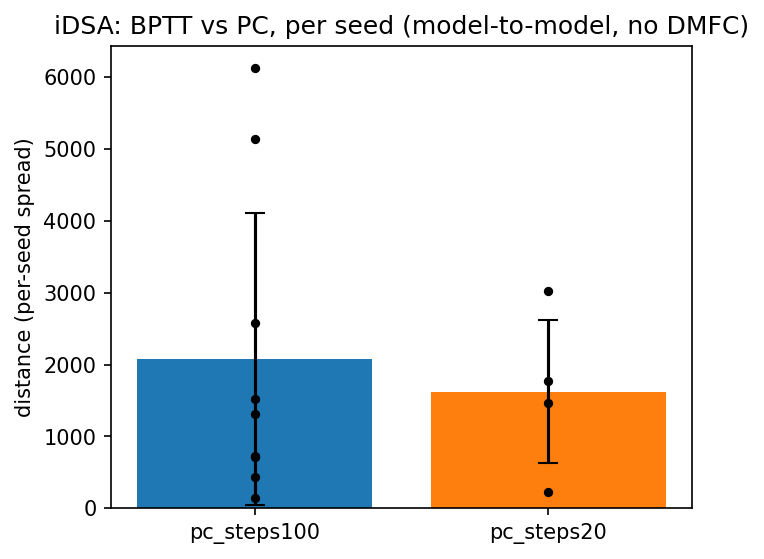

In [13]:
display(Image(filename=REPO_ROOT / "results/rsa/summary_pc_steps_comparison.png"))
display(Image(filename=REPO_ROOT / "results/idsa/summary_pc_steps_comparison.png"))

## Not included in this notebook

- **The `dsa-metric` official-package cross-check.** The DMFC comparison below uses
  iDSA's `builtin` numpy backend only, same as the model-to-model section above —
  `tests/test_idsa_backends.py` (which needs the separate `dsa-metric` env) has not
  been re-run against the real DMFC tensors.
- **PC's fixed-point collapse is not resolved.** The DMFC comparison below includes
  every PC seed exactly as trained (AGENTS.md: no behavioral filtering), including the
  ones already shown above to collapse to `ts`-independent fixed points. Its distance
  to DMFC is a real number but should be read next to that finding, not instead of it.


## BPTT vs PC vs RFLO: RSA / iDSA distance to DMFC

DMFC neural data (DANDI 000130, NLB `DMFC_RSG`) ingested via `src/data/build_neural.py`
into `data/processed/` — 54 units, 983/1160 trials resolved into the 20 canonical
conditions, `bin_ms=20`, `smooth_ms=40`, Ready-aligned on the model's own canvas.
Computed via `scripts/run_rsa.py --neural` / `scripts/run_idsa.py --neural --backend
builtin`, through the SAME `Preprocessor` instance as the neural reference (AGENTS.md,
"identical preprocessing"). RSA carries a noise ceiling from the neural split-halves;
iDSA does not (no split-half operator estimate implemented yet).

Same seed coverage as the model-to-model section above: `bptt`/`rflo` 10/10, `pc_steps20`
seeds 1/5/7/9 only (activation-store collision, see top of notebook), `pc_steps100` all
but seed 1 (incomplete run). No seed excluded on behavioral grounds — PC's collapsed
seeds are compared to DMFC exactly like every other seed.

In [14]:
import json

DMFC_ARMS = ["bptt", "rflo", "pc_steps20", "pc_steps100"]
_RULE_KEY = {"bptt": "bptt", "rflo": "rflo", "pc_steps20": "pc", "pc_steps100": "pc"}

rsa_dmfc = {}
noise_ceiling = None
for arm in DMFC_ARMS:
    payload = json.loads((REPO_ROOT / f"results/rsa/{arm}_vs_dmfc/rsa_distances.json").read_text())
    rsa_dmfc[arm] = payload["distances"]["RSA"][_RULE_KEY[arm]]
    if noise_ceiling is None and payload.get("noise_ceiling"):
        noise_ceiling = payload["noise_ceiling"]["RSA"]

idsa_dmfc = {}
idsa_components_dmfc = {}
for arm in DMFC_ARMS:
    payload = json.loads((REPO_ROOT / f"results/idsa/{arm}_vs_dmfc/idsa_distances.json").read_text())
    idsa_dmfc[arm] = payload["distances"][_RULE_KEY[arm]]
    idsa_components_dmfc[arm] = payload["components"]

display(Markdown(f"**RSA noise ceiling (neural split-half consistency): "
                  f"[{noise_ceiling[0]:.4f}, {noise_ceiling[1]:.4f}]**"))

**RSA noise ceiling (neural split-half consistency): [0.0086, 0.0324]**

In [15]:
_SEEDS_BY_ARM = {
    "bptt": list(range(10)),
    "rflo": list(range(10)),
    "pc_steps20": [1, 5, 7, 9],
    "pc_steps100": [0, 2, 3, 4, 5, 6, 7, 8, 9],
}

rsa_dmfc_rows = [
    {"arm": arm, "seed": seed, "rsa_distance": d}
    for arm in DMFC_ARMS
    for seed, d in zip(_SEEDS_BY_ARM[arm], rsa_dmfc[arm])
]
rsa_dmfc_df = pd.DataFrame(rsa_dmfc_rows)
display(Markdown("**RSA distance to DMFC, per seed**"))
display(rsa_dmfc_df)
display(rsa_dmfc_df.groupby("arm")["rsa_distance"].agg(["mean", "std"]).round(4).reindex(DMFC_ARMS))

**RSA distance to DMFC, per seed**

,arm,seed,rsa_distance
0,bptt,0,0.330736
1,bptt,1,0.336608
2,bptt,2,0.318283
3,bptt,3,0.183457
4,bptt,4,0.196593
5,bptt,5,0.233019
6,bptt,6,0.190819
7,bptt,7,0.307012
8,bptt,8,0.173495
9,bptt,9,0.371471


,mean,std
arm,,
bptt,0.2641,0.0757
rflo,0.2411,0.1305
pc_steps20,0.3566,0.0207
pc_steps100,0.4479,0.1062


In [16]:
idsa_dmfc_rows = [
    {"arm": arm, "seed": seed, **idsa_components_dmfc[arm][f"{_RULE_KEY[arm]}:{seed}"]}
    for arm in DMFC_ARMS
    for seed in _SEEDS_BY_ARM[arm]
]
idsa_dmfc_df = pd.DataFrame(idsa_dmfc_rows)
display(Markdown("**iDSA distance to DMFC, per seed** (`distance` = combined; "
                  "`state_distance` / `input_distance` = its recurrent- vs input-structure components)"))
display(idsa_dmfc_df)
display(idsa_dmfc_df.groupby("arm")[["distance", "state_distance", "input_distance"]]
        .agg(["mean", "std"]).round(2).reindex(DMFC_ARMS))

**iDSA distance to DMFC, per seed** (`distance` = combined; `state_distance` / `input_distance` = its recurrent- vs input-structure components)

,arm,seed,distance,input_distance,state_distance
0,bptt,0,5.430939,1.973421,2.143312
1,bptt,1,4.838056,1.344165,2.245198
2,bptt,2,3.071816,0.428697,1.821211
3,bptt,3,4.281008,1.260385,1.836218
4,bptt,4,6.301936,1.218533,2.663771
5,bptt,5,3.610375,0.803251,2.195926
6,bptt,6,5.832929,1.468798,2.191049
7,bptt,7,3.889351,0.533567,2.591116
8,bptt,8,3.351541,0.813093,1.744124
9,bptt,9,4.276853,0.999736,2.582306


distance       state_distance       input_distance      
                mean   std           mean   std           mean   std
arm                                                                 
bptt            4.49  1.09           2.20  0.33           1.08  0.47
rflo            4.76  1.01           1.94  0.19           0.98  0.43
pc_steps20      8.02  0.37           3.02  0.58           3.20  0.09
pc_steps100     8.15  0.35           5.20  4.96           3.40  0.35

### Combined summary: distance to DMFC, all four arms

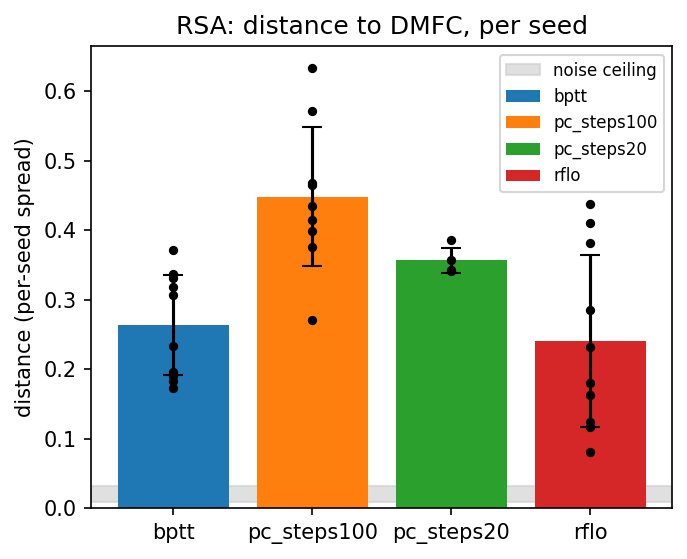

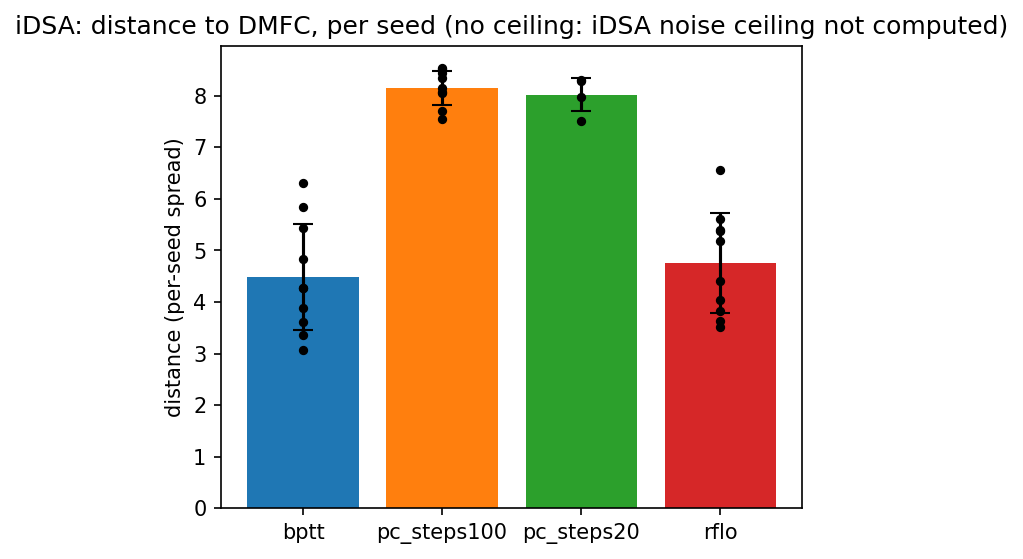

In [17]:
display(Image(filename=REPO_ROOT / "results/rsa/summary_dmfc_comparison.png"))
display(Image(filename=REPO_ROOT / "results/idsa/summary_dmfc_comparison.png"))

### Key finding: PC sits farthest from DMFC on both metrics

- **RSA**: `bptt` (mean 0.264) and `rflo` (mean 0.241) are closest to DMFC and
  comparable to each other; `pc_steps20` (mean 0.357) and `pc_steps100` (mean 0.448)
  are both farther, with `pc_steps100` the farthest of all four. All four are well
  above the neural noise ceiling — none of the models reach split-half neural
  consistency, expected for a first pass at this comparison.
- **iDSA**: the separation is sharper. `bptt` (mean 4.49) and `rflo` (mean 4.76) are
  close together; both `pc` variants are markedly farther (`pc_steps20` mean 8.02,
  `pc_steps100` mean 8.15) — roughly double BPTT/RFLO's distance, on a metric with no
  shared scale ceiling to compress the gap.
- Read alongside the parked finding at the top of this notebook and in
  `.suplex/handoffs/history/2026-07-23_pc_train_eval_loss_discrepancy_parked.md`: PC's
  `forward()` rollout provably collapses to 4 `ts`-independent fixed points (one per
  prior×effector group). A model whose dynamics do not depend on `ts` at all is
  expected to look dynamically dissimilar from DMFC, which does encode `ts` — the iDSA
  gap here is consistent with, not independent evidence for, that mechanism.
- This is a single ingestion pass, one noise-ceiling estimate, and — per AGENTS.md
  ("seeds are the unit of evidence") — the per-seed spread above, not this paragraph,
  is the actual result. Read the tables, not just the means.